# 03 — Mini Challenge & Complete Anomaly Detection Pipeline

**Hour 2, 105–120 min: Mini challenge, business interpretation, and the full pipeline**

Two things happen in this notebook:
1. A **mini challenge** — see with your own eyes how the `contamination` parameter changes
   what gets flagged.
2. Putting everything together into **one complete, reusable pipeline** — the capstone shape
   from the slides:

```
Raw Transactions → Data Exploration → Feature Selection → Preprocessing →
Isolation Forest → Anomaly Detection → Visualization → Investigation →
Business Recommendation
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (9, 5.5)

df = pd.read_csv("../data/bank_transaction_anomaly_dataset.csv")
feature_cols = ["transaction_amount", "transaction_frequency", "transaction_hour",
                 "distance_from_usual_location_km", "account_age_days"]
X_scaled = StandardScaler().fit_transform(df[feature_cols])
df.shape

(5004, 8)

## Mini Challenge: How Does `contamination` Change the Result?

**The task:** Train Isolation Forest with a few different `contamination` values and compare
how many anomalies get flagged, and how that affects our (synthetic) precision/recall.

Try `contamination="auto"`, and reasonable alternatives like `0.01` and `0.05`. As you run
this, ask yourself:
- How many anomalies were detected at each setting?
- Why did the number change?
- Does flagging MORE anomalies mean a BETTER model?
- What could happen if we flag too MANY customers as suspicious?
- What could happen if we flag too FEW?

In [2]:
contamination_values = [0.01, 0.03, 0.05, "auto"]
results = []

for c in contamination_values:
    model = IsolationForest(n_estimators=100, contamination=c, random_state=42)
    model.fit(X_scaled)
    pred = (model.predict(X_scaled) == -1).astype(int)

    tp = ((pred == 1) & (df["is_actual_anomaly"] == 1)).sum()
    fp = ((pred == 1) & (df["is_actual_anomaly"] == 0)).sum()
    fn = ((pred == 0) & (df["is_actual_anomaly"] == 1)).sum()
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0

    results.append({
        "contamination": c,
        "flagged": pred.sum(),
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "precision": round(precision, 2),
        "recall": round(recall, 2),
    })

results_df = pd.DataFrame(results)
results_df

,contamination,flagged,true_positives,false_positives,false_negatives,precision,recall
0,0.01,51,51,0,103,1.00,0.33
1,0.03,151,147,4,7,0.97,0.95
2,0.05,251,154,97,0,0.61,1.00
3,auto,456,154,302,0,0.34,1.00


**What do we see?**
- `contamination=0.01` flags the fewest transactions, with very high precision but it MISSES
  some real anomalies (lower recall) — it's conservative.
- `contamination="auto"` flags the most transactions. It catches essentially every real
  anomaly (high recall) but drags in a large number of false positives (much lower precision).
- `contamination=0.03` — close to the dataset's true anomaly rate (~3%) — gives the best
  balance of precision and recall here.

**Does more anomalies mean a better model?** No. More flagged transactions usually means more
false positives, not necessarily more real fraud caught (look at how `true_positives` barely
changes between 0.03, 0.05 and auto, while `false_positives` grows a lot).

**Business risk of flagging too MANY:** Investigators waste time on false alarms, customers
get annoyed by unnecessary friction (e.g. blocked cards), and genuine urgent cases can get
lost in the noise.

**Business risk of flagging too FEW:** Real fraud slips through undetected — the more
expensive kind of mistake in most fraud scenarios.

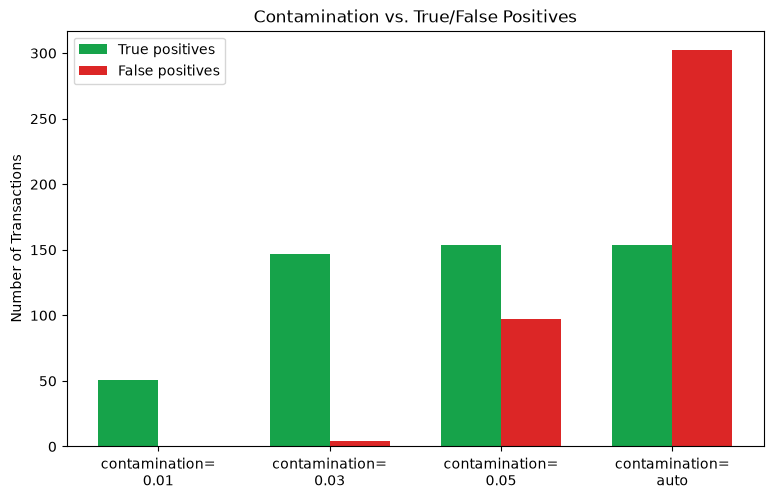

In [3]:
fig, ax = plt.subplots(figsize=(9, 5.4))
x = np.arange(len(contamination_values))
w = 0.35
ax.bar(x - w/2, results_df["true_positives"], width=w, color="#16A34A", label="True positives")
ax.bar(x + w/2, results_df["false_positives"], width=w, color="#DC2626", label="False positives")
ax.set_xticks(x)
ax.set_xticklabels([f"contamination=\n{c}" for c in contamination_values])
ax.set_ylabel("Number of Transactions")
ax.set_title("Contamination vs. True/False Positives")
ax.legend()
plt.show()

## The Complete Pipeline

Now let's wrap everything into one clean, reusable function — the kind of thing you'd actually
keep in a real project.

In [4]:
def detect_anomalies(csv_path, feature_cols, contamination=0.03, random_state=42):
    """
    Runs the full anomaly detection pipeline on a transaction CSV and
    returns the DataFrame with predictions and anomaly scores attached.
    """
    # 1. Raw data
    data = pd.read_csv(csv_path)

    # 2. Feature selection
    X = data[feature_cols].copy()

    # 3. Preprocessing
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 4. Isolation Forest
    model = IsolationForest(n_estimators=100, contamination=contamination, random_state=random_state)
    model.fit(X_scaled)

    # 5. Anomaly detection
    data["is_anomaly"] = (model.predict(X_scaled) == -1).astype(int)
    data["anomaly_score"] = model.score_samples(X_scaled)

    return data.sort_values("anomaly_score")


result = detect_anomalies(
    "../data/bank_transaction_anomaly_dataset_unlabeled.csv",
    feature_cols=feature_cols,
    contamination=0.03,
)
print(f"Flagged {result['is_anomaly'].sum()} of {len(result)} transactions.")
result.head(10)

Flagged 151 of 5004 transactions.


,transaction_id,customer_id,transaction_amount,transaction_frequency,transaction_hour,distance_from_usual_location_km,account_age_days,is_anomaly,anomaly_score
2361,TXN502361,CUST20846,667451,1,2,382.5,3234,1,-0.737202
3960,TXN503960,CUST20439,439164,3,1,306.7,3504,1,-0.736738
1449,TXN501449,CUST20531,471188,3,1,359.4,1907,1,-0.734296
3181,TXN503181,CUST20087,875490,3,3,270.6,224,1,-0.733356
3475,TXN503475,CUST20517,672373,3,2,253.8,666,1,-0.732963
4747,TXN504747,CUST20256,12260,30,0,18.2,823,1,-0.732658
663,TXN500663,CUST20256,4690,30,0,16.7,823,1,-0.728948
3304,TXN503304,CUST20256,45052,30,0,24.4,823,1,-0.728868
3347,TXN503347,CUST20256,51102,30,0,22.5,823,1,-0.728868
4022,TXN504022,CUST20015,840081,3,3,320.7,2132,1,-0.728499


## Investigation: The Top 5 Most Unusual Transactions

An investigator wouldn't look at all 150 flagged transactions at once — they'd start with the
MOST unusual ones first.

In [5]:
top5 = result.head(5)
top5[["transaction_id", "customer_id", "transaction_amount", "transaction_frequency",
      "transaction_hour", "distance_from_usual_location_km", "anomaly_score"]]

,transaction_id,customer_id,transaction_amount,transaction_frequency,transaction_hour,distance_from_usual_location_km,anomaly_score
2361,TXN502361,CUST20846,667451,1,2,382.5,-0.737202
3960,TXN503960,CUST20439,439164,3,1,306.7,-0.736738
1449,TXN501449,CUST20531,471188,3,1,359.4,-0.734296
3181,TXN503181,CUST20087,875490,3,3,270.6,-0.733356
3475,TXN503475,CUST20517,672373,3,2,253.8,-0.732963


## Business Recommendation

The model flagged around 150 transactions as anomalies.

**Does that mean 150 transactions are fraudulent?**

**No.** The model has identified UNUSUAL behaviour — not confirmed fraud. The complete
real-world workflow looks like this:

```
Data → Anomaly Detection Model → Flagged Transactions → Investigation →
Business Validation → Fraud / Legitimate / Other Outcome → Feedback into the system
```

A sensible next step for the bank:
1. Route the top-ranked (lowest anomaly score) transactions to a human fraud analyst first.
2. For contextual anomalies (unusual hour + distance), consider automated soft actions like an
   SMS/email confirmation prompt rather than an outright block.
3. Track which flagged transactions turn out to be real fraud vs. legitimate — feed that back
   in over time to refine the `contamination` estimate and feature set.
4. Re-run detection periodically — customer behaviour and fraud patterns both drift, so a model
   trained once should not be trusted forever.

### Recap
- We saw concretely how `contamination` trades off false positives against false negatives.
- We built one reusable `detect_anomalies()` function covering the entire pipeline.
- We practiced going from "flagged transactions" to an actual business recommendation —
  not just a number.

**This is the shape of your capstone project** — see `exercises/anomaly_detection_exercise.ipynb`
to apply it yourself.